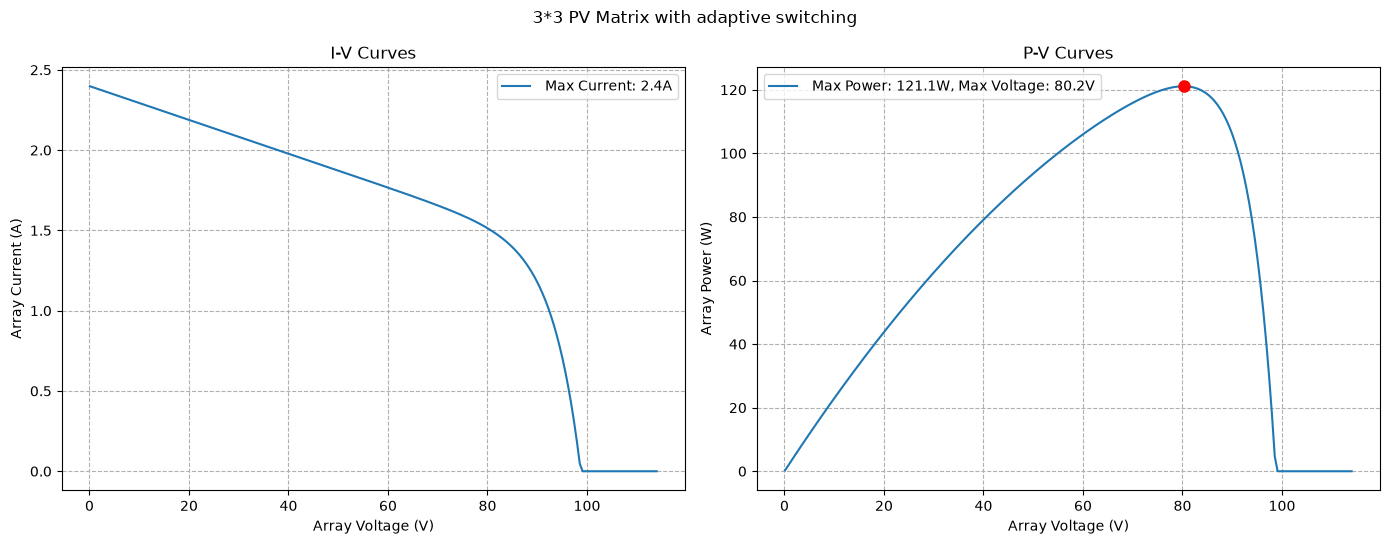

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root

def extract_villalva_parameters(Voc_n, Isc_n, Ns, a=1.3):
    q, k, T_n = 1.60217663e-19, 1.380649e-23, 298.15
    Vt = (Ns * k * T_n) / q
    
    Rp = (Voc_n / 0.05) / Isc_n  
    Rs = 0.01 * (Voc_n / Isc_n)
    I0_n = (Isc_n - (Voc_n - Isc_n * Rs) / Rp) / (np.exp(Voc_n / (n * Vt)) - 1.0)
    
    return [Voc_n, Isc_n, Rs, Rp, I0_n, Vt]


VOC, ISC, Ns = 38, 8, 54     
def extract_villalva_parameters(Voc_n, Isc_n, Ns, n=1.3):
    q, k, T_n = 1.60e-19, 1.38e-23, 298.15
    Vt = (Ns * k * T_n) / q

    Rp = (Voc_n / 0.05) / Isc_n
    Rs = 0.01 * (Voc_n / Isc_n)
    I0_n = (Isc_n - (Voc_n - Isc_n * Rs) / Rp) / (np.exp(Voc_n / (n * Vt)) - 1.0)

    return [Voc_n, Isc_n, Rs, Rp, I0_n, Vt]

pv_params = extract_villalva_parameters(VOC, ISC, Ns)


def solve_module_current_with_bypass(V, G, pv_params, n =1.3):

    Voc_n, Isc_n, Rs, Rp, I0_n, Vt = pv_params
    
    Ipv = (G / 1000.0) * Isc_n if G > 1.0 else 0.0
    
    I_guess = Ipv
    for _ in range(15):
        vd_over_avt = (V + I_guess * Rs) / (n * Vt)
        vd_over_avt = min(50.0, max(-50.0, vd_over_avt)) 
        
        expr = np.exp(vd_over_avt)
        f = Ipv - I0_n * (expr - 1.0) - (V + I_guess * Rs) / Rp - I_guess
        df = -I0_n * (Rs / (n * Vt)) * expr - (Rs / Rp) - 1.0
        
        I_guess -= f / df
        
    I0_bd = 1e-6
    Vt_bd = 0.026 
    
    v_bd_ratio = -V / Vt_bd
    v_bd_ratio = min(50.0, max(-50.0, v_bd_ratio))
    I_bypass = I0_bd * (np.exp(v_bd_ratio) - 1.0)
    
    # Total current leaving the module assembly is the sum of both paths
    return I_guess + I_bypass

def solve_mna_network(V_array, shading_matrix, switches, pv_params, initial_guess):
    flat_G = np.array(shading_matrix).flatten()

    def residual(variables):
        v10, v11, v12 = variables[0], variables[1], variables[2]
        v20, v21, v22 = variables[3], variables[4], variables[5]
        i_s1a, i_s1b  = variables[6], variables[7]
        i_s2a, i_s2b  = variables[8], variables[9]

        I0 = solve_module_current_with_bypass(V_array - v10, flat_G[0], pv_params)
        I1 = solve_module_current_with_bypass(V_array - v11, flat_G[1], pv_params)
        I2 = solve_module_current_with_bypass(V_array - v12, flat_G[2], pv_params)
        
        I3 = solve_module_current_with_bypass(v10 - v20, flat_G[3], pv_params)
        I4 = solve_module_current_with_bypass(v11 - v21, flat_G[4], pv_params)
        I5 = solve_module_current_with_bypass(v12 - v22, flat_G[5], pv_params)
        
        I6 = solve_module_current_with_bypass(v20 - 0, flat_G[6], pv_params)
        I7 = solve_module_current_with_bypass(v21 - 0, flat_G[7], pv_params)
        I8 = solve_module_current_with_bypass(v22 - 0, flat_G[8], pv_params)

        res = np.zeros(10)
        
        # residual equations for KCL at each node
        res[0] = I0 - I3 - i_s1a             
        res[1] = I1 - I4 + i_s1a - i_s1b     
        res[2] = I2 - I5 + i_s1b             
        res[3] = I3 - I6 - i_s2a             
        res[4] = I4 - I7 + i_s2a - i_s2b     
        res[5] = I5 - I8 + i_s2b             

        # Switch State Constraints using KVL
        res[6] = v10 - v11 if switches['S1_a'] else i_s1a
        res[7] = v11 - v12 if switches['S1_b'] else i_s1b
        res[8] = v20 - v21 if switches['S2_a'] else i_s2a
        res[9] = v21 - v22 if switches['S2_b'] else i_s2b

        return res

    sol = root(residual, initial_guess, method='hybr')
    updated_guess = list(sol.x)
    
    v10_f, v11_f, v12_f = sol.x[0], sol.x[1], sol.x[2]
    total_current = (solve_module_current_with_bypass(V_array - v10_f, flat_G[0], pv_params) +
                     solve_module_current_with_bypass(V_array - v11_f, flat_G[1], pv_params) +
                     solve_module_current_with_bypass(V_array - v12_f, flat_G[2], pv_params))
                     
    return max(0.0, total_current), updated_guess

shading = [ [100, 100, 100],  
            [100, 100, 100], 
            [100, 100, 100]   ]

switches = {'S1_a': True, 'S1_b': True, 'S2_a': True, 'S2_b': False}

v_sweep = np.linspace(0.1, 3 * VOC, 200)
adapt_currents, adapt_powers = [], []

guess_adapt = [2*v_sweep[0]/3]*3 + [v_sweep[0]/3]*3 + [0.0]*4

for v in v_sweep:
    
    i_adapt, guess_adapt = solve_mna_network(v, shading, switches, pv_params, guess_adapt)
    adapt_currents.append(i_adapt)
    adapt_powers.append(v * i_adapt)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# I-V 
ax1.plot(v_sweep, adapt_currents, label =f' Max Current: {max(adapt_currents):.1f}A')
ax1.set_title(" I-V Curves ")
ax1.set_xlabel("Array Voltage (V)")
ax1.set_ylabel("Array Current (A)")
ax1.grid(True, linestyle="--")
ax1.legend()

# P-V 
ax2.plot(v_sweep, adapt_powers,  label=f' Max Power: {max(adapt_powers):.1f}W, Max Voltage: {v_sweep[np.argmax(adapt_powers)]:.1f}V')
ax2.plot(v_sweep[np.argmax(adapt_powers)], max(adapt_powers), 'ro', markersize=8)
ax2.set_title("P-V Curves")
ax2.set_xlabel("Array Voltage (V)")
ax2.set_ylabel("Array Power (W)")
ax2.grid(True, linestyle="--")
ax2.legend()

plt.suptitle("3*3 PV Matrix with adaptive switching")
plt.tight_layout()
plt.show()